***Environment Setup & Library Imports***

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

***Data Loading & Dimensionality Reduction***

In [3]:
### Loading the raw dataset and mathematically aggregating the 20 initial features into 7 distinct features to reduce model complexity

train_df = pd.read_csv('train.csv')

X = pd.DataFrame()
X['Climate_Risk'] = train_df[['MonsoonIntensity', 'ClimateChange', 'CoastalVulnerability']].mean(axis=1)
X['Geological_Risk'] = train_df[['TopographyDrainage', 'Landslides', 'Watersheds']].mean(axis=1)
X['Human_Impact'] = train_df[['Deforestation', 'Urbanization']].mean(axis=1) 
X['Infrastructure_Deficit'] = train_df[['DamsQuality', 'DrainageSystems', 'DeterioratingInfrastructure']].mean(axis=1)
X['Environmental_Degradation'] = train_df[['Siltation', 'AgriculturalPractices', 'WetlandLoss']].mean(axis=1)
X['Management_Failures'] = train_df[['RiverManagement', 'IneffectiveDisasterPreparedness', 'InadequatePlanning']].mean(axis=1)
X['Encroachment_Level'] = train_df['Encroachments']

y = train_df['FloodProbability']

print("Dataset shape:", X.shape)

Dataset shape: (1117957, 7)


***Feature Distributions and Visualization***

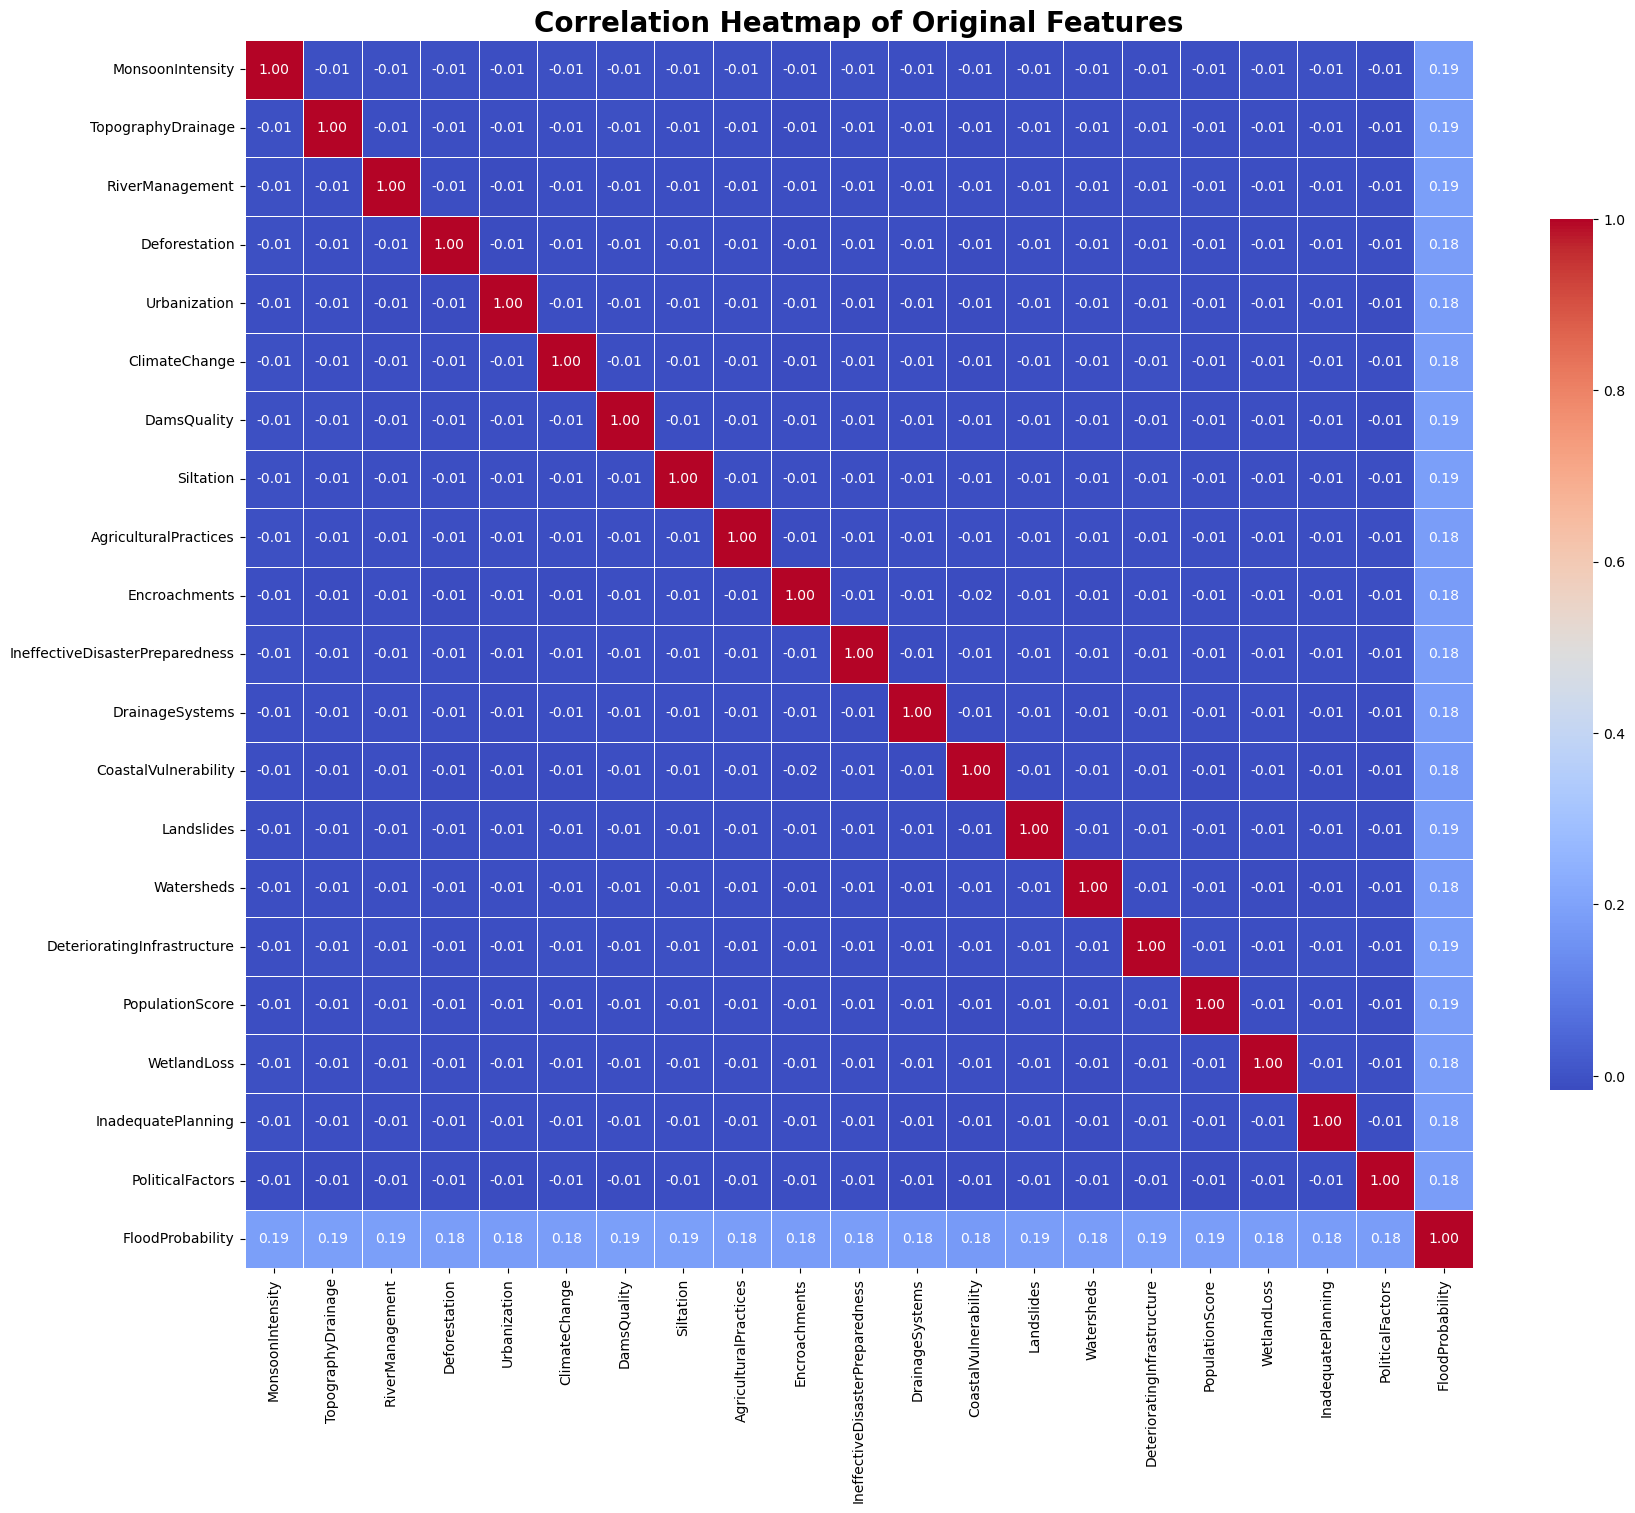

In [5]:
# Calculate the correlation matrix on the raw data (dropping the 'id' column)
corr_matrix = train_df.drop(columns=['id']).corr()

plt.figure(figsize=(18, 15))

# Render the heatmap
sns.heatmap(
    corr_matrix,  
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .7}
)

plt.title("Correlation Heatmap of Original Features", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

***Splitting data into Training (80%) and Validation (20%)***

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

***Normalization of Dataset***

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

***Model Initialization***

**Linear Regression Baseline**

In [6]:
###Initializing and training the standard parametric linear model.
linear_model = LinearRegression()
start_time = time.time()
linear_model.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.2f} seconds.")

joblib.dump(linear_model, 'linear_model.pkl')

Training completed in 0.30 seconds.


['linear_model.pkl']

**Decision Tree Regressor**

In [7]:
###Initializing and training the non-parametric decision tree model
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
start_time = time.time()
dt_model.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.2f} seconds.")

joblib.dump(dt_model, 'dt_model.pkl')

Training completed in 5.83 seconds.


['dt_model.pkl']

**Multi-Layer Perceptron (Neural Network)**

In [8]:
###Initializing and training the deep learning perceptron
mlp_model = MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42, early_stopping=True)
start_time = time.time()
mlp_model.fit(X_train_scaled, y_train)
elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.2f} seconds.")

joblib.dump(mlp_model, 'mlp_model.pkl')

Training completed in 333.71 seconds.


['mlp_model.pkl']

***Model Evaluation***

In [9]:
###Evaluating all three standalone models against the Validation Set using advanced error metrics
print("-" * 85)
print(f"{'Model Name':<20} | {'R-squared':<10} | {'MSE':<10} | {'RMSE':<10} | {'MAE':<10} | {'MAPE':<10}")
print("-" * 85)

# Grouping the newly trained individual models into a temporary dictionary just for evaluation
eval_models = {
    "Linear Regression": linear_model,
    "Decision Tree": dt_model,
    "Perceptron (MLP)": mlp_model
}

for name, model in eval_models.items():
    # Select appropriate validation set
    if "MLP" in name:
        preds = model.predict(X_val_scaled)
    else:
        preds = model.predict(X_val)
        
    # Calculate metrics
    r2 = r2_score(y_val, preds)
    mse = mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, preds)
    mape = mean_absolute_percentage_error(y_val, preds)
    
    # Print formatted row
    print(f"{name:<20} | {r2:.6f}   | {mse:.6f}   | {rmse:.6f}   | {mae:.6f}   | {mape:.6f}")

print("-" * 85)

-------------------------------------------------------------------------------------
Model Name           | R-squared  | MSE        | RMSE       | MAE        | MAPE      
-------------------------------------------------------------------------------------
Linear Regression    | 0.740051   | 0.000676   | 0.025994   | 0.020819   | 0.041982
Decision Tree        | 0.549047   | 0.001172   | 0.034237   | 0.027511   | 0.055387
Perceptron (MLP)     | 0.745614   | 0.000661   | 0.025714   | 0.020569   | 0.041409
-------------------------------------------------------------------------------------


***Feature Dependency***

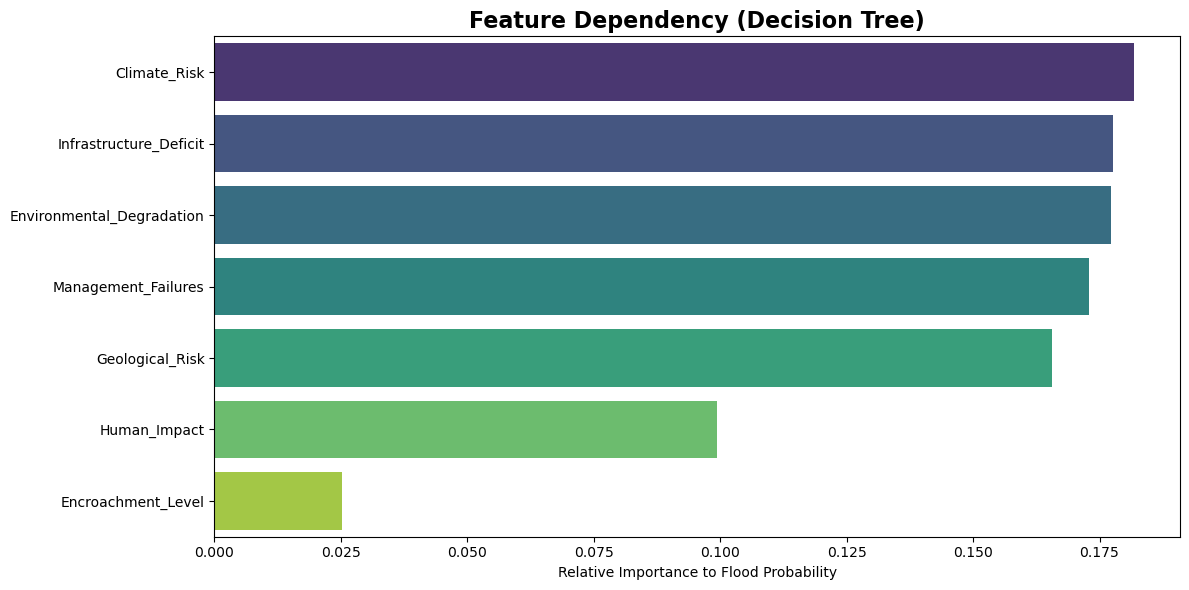

In [10]:
# Load the trained model
dt_model = joblib.load('dt_model.pkl')

# Extract the mathematical importance scores
importances = dt_model.feature_importances_
    
# Create a DataFrame and sort it for a clean visualization
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
    
# Render the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis',legend=False)
plt.title("Feature Dependency (Decision Tree)", fontsize=16, fontweight='bold')
plt.xlabel("Relative Importance to Flood Probability")
plt.ylabel("")
plt.tight_layout()
plt.show()